In [1]:
# Library

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Feature Engineering
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
import category_encoders as ce

# Model Selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV,StratifiedKFold,train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score

# Imbalance Dataset
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

In [2]:
# Load the dataset 
df = pd.read_csv("bank-additional-full.csv", sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# 1. Define Problem and Data Understanding

- **Stakeholder Identification**

Who is the stakeholder?

The stakeholder is likely a bank or financial institution that is running marketing campaigns to promote a specific product (e.g., term deposits).

They are interested in improving the success rate of their campaigns by identifying which customers are more likely to subscribe to the product.

- **Problem Statement**

What is the problem?

The bank is facing challenges in converting leads into customers during their marketing campaigns. Specifically, they have a low success rate in getting customers to subscribe to term deposits.

This inefficiency leads to wasted resources (time, money, and effort) on customers who are unlikely to convert.

Why is this problem important?

A low conversion rate directly impacts the bank’s revenue and profitability.

It also affects customer satisfaction if irrelevant offers are repeatedly made to uninterested customers.

Improving the campaign’s effectiveness can lead to better resource allocation and higher ROI.

- **Specific and Measurable Goals**

Goal: Increase the success rate of the marketing campaign by identifying high-potential customers using data-driven insights.

Target: Achieve at least a 20% increase in the conversion rate (from "no" to "yes" in the y column) by leveraging predictive modeling.

**The bank wants to improve the success rate of its marketing campaigns by predicting which customers are more likely to subscribe to term deposits. This will help optimize resource allocation and increase ROI.**

# Data Understanding

Dataset Overview

- Source of the Dataset:

This dataset appears to be sourced from a public repository, possibly the UCI Machine Learning Repository , which provides datasets for research and educational purposes.

It is commonly used for binary classification tasks in banking marketing campaigns.

- Creator of the Dataset:

The dataset was likely created by researchers or professionals in the banking industry who collected data from real-world marketing campaigns.

- When Was the Data Created?

Based on the features and context, the dataset seems to represent data collected over a period of time, likely spanning multiple months or years (e.g., campaigns conducted between 2008–2013).


**Description of Columns**

Here’s a detailed breakdown of the columns:

- age: Usia pelanggan.
- job: Pekerjaan pelanggan.
- marital: Status pernikahan.
- education: Tingkat pendidikan.
- default, housing, loan: Informasi kredit pelanggan.
- contact, month, day_of_week: Detail kontak.
- duration: Durasi kontak terakhir.
- campaign: Jumlah kontak selama kampanye ini.
- pdays: Hari terakhir kontak dari kampanye sebelumnya.
- previous: Jumlah kontak sebelum kampanye ini.
- poutcome: Hasil kampanye sebelumnya.
- emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed: Indikator ekonomi.
- y: Target variabel (yes/no).

**The dataset provides comprehensive information about customer profiles, campaign interactions, and economic indicators. It is relevant to the problem but may require preprocessing to address challenges like class imbalance and feature engineering.**

 # 2. Data Cleaning & Preprocessing

 **Initial Data Inspection**

In [3]:
# Get summary statistics for numerical columns
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [4]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

Our dataset has no missing value.

In [5]:
df = df.drop_duplicates()

Our dataset contains:

1. Numerical Features : age, duration, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed.

2. Categorical Features : job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome.

3. Target Variable : y (binary: "yes" or "no").

## Outliers

We will manually capping the extreme outliers from the data using 'waterfall' method. We will continue to monitoring the amount of data for each feature that has been capped. So there will be not much data is wasted.

In [6]:
num_features = list(df.describe().columns)
num_features

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

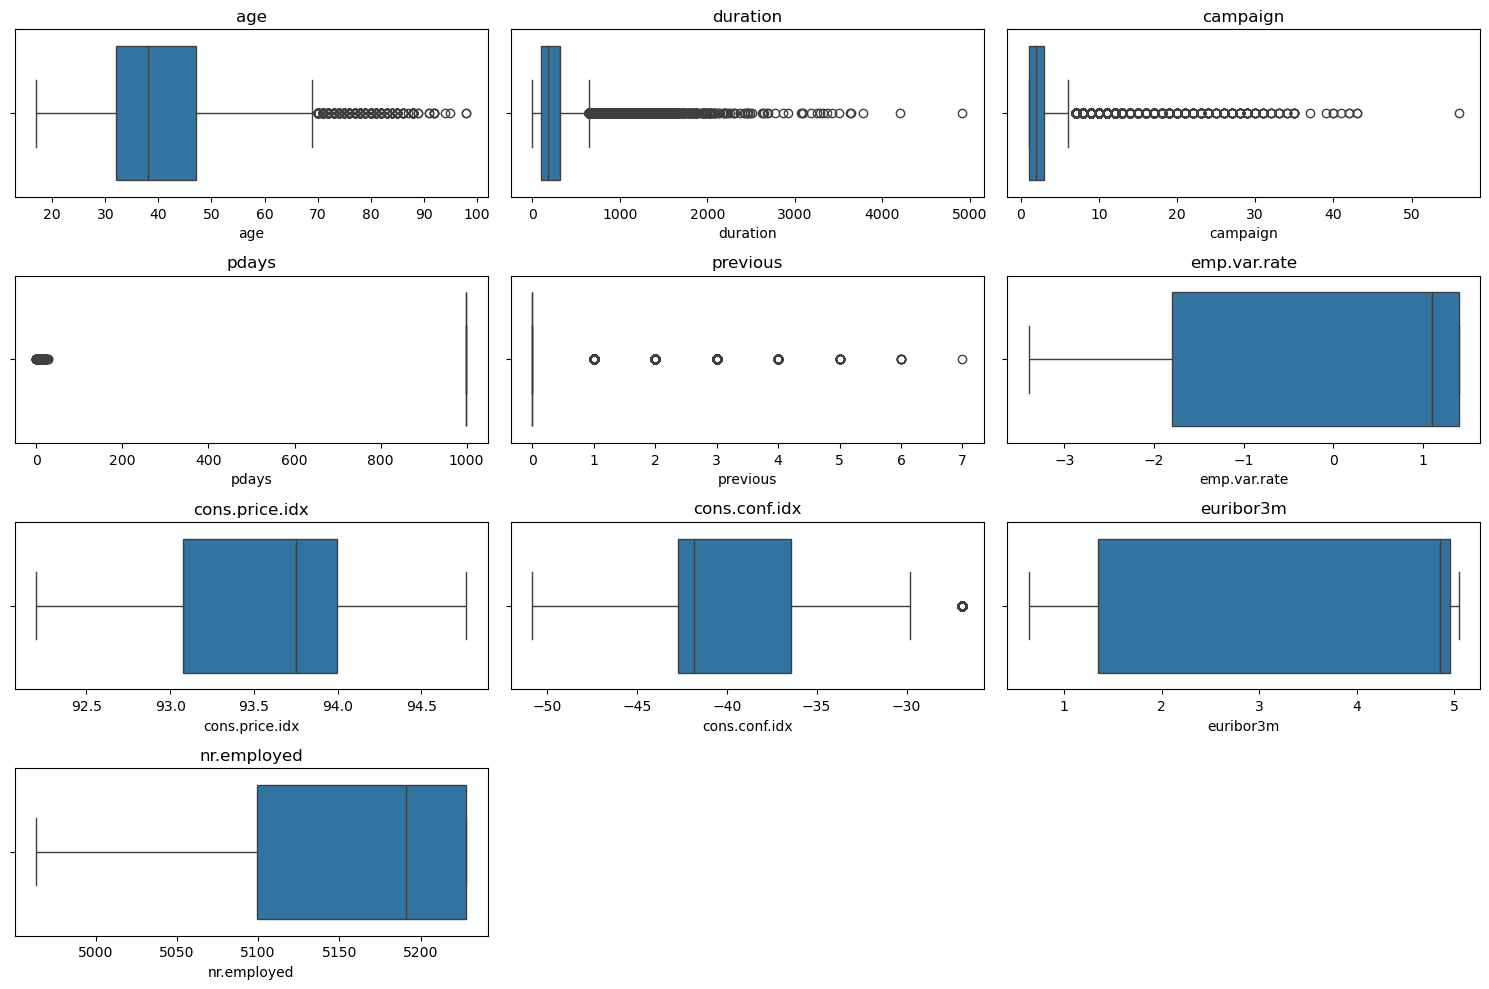

In [7]:
plt.figure(figsize=(15, 10))

plot_number = 1
for feat in num_features:
    plt.subplot(4, 3, plot_number) 
    sns.boxplot(data=df, x=feat)
    plt.title(feat)
    plt.tight_layout()  
    plot_number += 1

plt.show()

In [8]:
df = df[df['pdays'] > 800]
display(df)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [9]:
df.shape

(39661, 21)

In [10]:
# drop outliers age
df = df[~(df['age'] > 90)]
df.shape 

(39655, 21)

In [11]:
# drop outliers duration
df = df[~(df['duration'] > 2500)]
df.shape 

(39632, 21)

In [12]:
# drop outliers campaign
df = df[~(df['campaign'] > 30)]
df.shape 

(39599, 21)

In [13]:
# drop outliers previous
df = df[~(df['previous'] > 3)]
df.shape 

(39584, 21)

## Splitting the Data

We split the data into training and testing sets before preprocessing to avoid data leakage.

In [14]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(columns=['y'])  # Features
y = df['y']  # Target

# Split the data into training and testing sets (80:20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

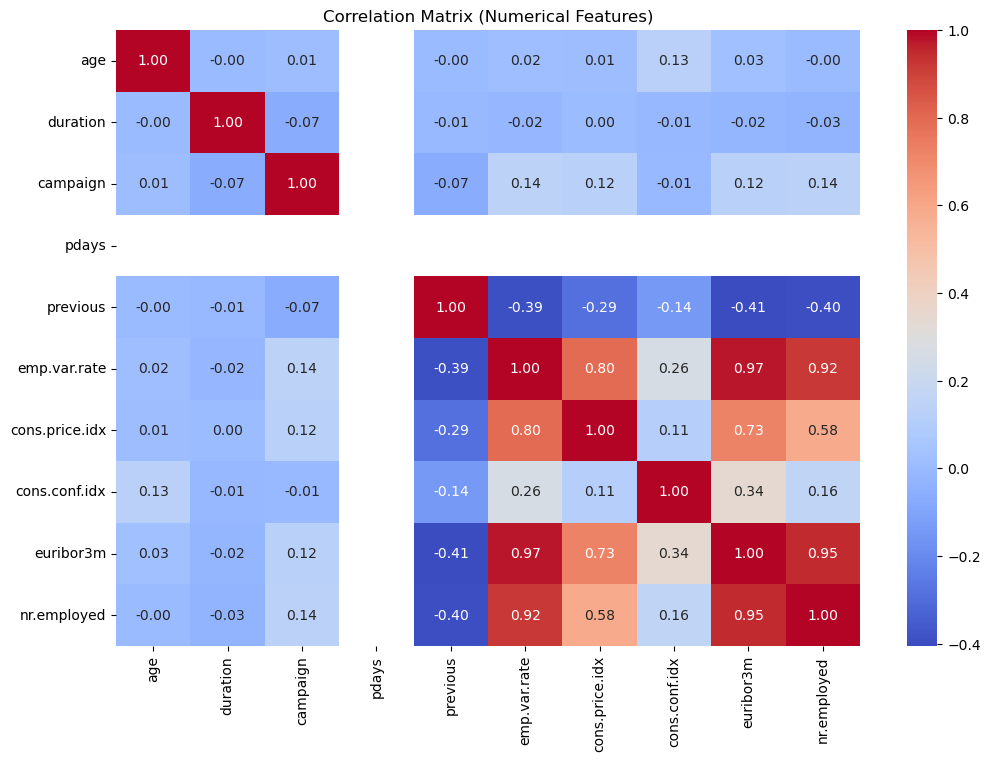

VIF Values:
          Feature            VIF
3           pdays  548066.972307
8       euribor3m      63.047750
5    emp.var.rate      33.231808
9     nr.employed      30.318748
6  cons.price.idx       6.085807
7   cons.conf.idx       2.768253
4        previous       1.202910
2        campaign       1.036251
0             age       1.018551
1        duration       1.007179


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Identify numerical columns
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Compute the correlation matrix for numerical features
correlation_matrix = X_train[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Numerical Features)')
plt.show()

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Calculate VIF for numerical features only
vif_data = pd.DataFrame()
vif_data["Feature"] = numerical_cols
vif_data["VIF"] = [variance_inflation_factor(X_train[numerical_cols].values, i) for i in range(len(numerical_cols))]

# Display VIF values
print("VIF Values:")
print(vif_data.sort_values(by='VIF', ascending=False))

### Addressing Multicollinearity

Based on the correlation matrix and VIF results, we’ll remove redundant features to reduce multicollinearity. Here’s the plan:

1. Remove pdays:
    - The extremely high VIF (548,066.97) indicates that pdays is causing severe multicollinearity. It should be removed.

2. Handle the Economic Indicators Cluster:
    - From the economic indicators cluster (emp.var.rate, euribor3m, nr.employed), keep only one representative feature.
    - Since euribor3m has the highest feature importance (as seen earlier), we’ll keep it and drop emp.var.rate and nr.employed.

3. Keep Other Features:
    - Features like cons.price.idx, cons.conf.idx, campaign, age, and duration have low-to-moderate VIF and are important predictors. We’ll retain them.

In [16]:
# List of features to drop
redundant_features = ['pdays', 'emp.var.rate', 'nr.employed']

# Drop redundant features
X_train_reduced = X_train.drop(columns=redundant_features)
X_test_reduced = X_test.drop(columns=redundant_features)

print(f"Reduced feature set: {list(X_train_reduced.columns)}")

Reduced feature set: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'previous', 'poutcome', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']


In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Identify numerical columns in the reduced feature set
numerical_cols_reduced = X_train_reduced.select_dtypes(include=['int64', 'float64']).columns

# Calculate VIF for the reduced feature set
vif_data_reduced = pd.DataFrame()
vif_data_reduced["Feature"] = numerical_cols_reduced
vif_data_reduced["VIF"] = [variance_inflation_factor(X_train_reduced[numerical_cols_reduced].values, i) 
                           for i in range(len(numerical_cols_reduced))]

# Display updated VIF values
print("Updated VIF Values:")
print(vif_data_reduced.sort_values(by='VIF', ascending=False))

Updated VIF Values:
          Feature         VIF
4  cons.price.idx  148.574324
5   cons.conf.idx   95.849433
0             age   16.725136
6       euribor3m    8.285260
1        duration    2.065740
2        campaign    1.989311
3        previous    1.321828


Some features still have relatively high VIF values (e.g., cons.price.idx and cons.conf.idx)

To further reduce multicollinearity, we’ll:

Drop cons.price.idx and cons.conf.idx:
These features have very high VIF values and are likely redundant. Dropping them will simplify the model without significant loss of predictive power.

The **duration** feature is highly predictive, but it can cause data leakage because it represents the duration of the last contact (in seconds) during the phone call. In a real-world scenario, this information is only available **after the call ends** , which means it cannot be used for prediction at the time of decision-making. Removing duration is a prudent step to ensure our model is realistic and deployable.

So, we decided to drop the duration feature from the dataset.

In [18]:
# List of additional features to drop
additional_redundant_features = ['cons.price.idx', 'cons.conf.idx', 'duration']

# Drop additional redundant features
X_train_reduced = X_train_reduced.drop(columns=additional_redundant_features)
X_test_reduced = X_test_reduced.drop(columns=additional_redundant_features)

print(f"Further reduced feature set: {list(X_train_reduced.columns)}")

Further reduced feature set: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome', 'euribor3m']


In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Identify numerical columns in the further reduced feature set
numerical_cols_reduced = X_train_reduced.select_dtypes(include=['int64', 'float64']).columns

# Calculate VIF for the further reduced feature set
vif_data_reduced = pd.DataFrame()
vif_data_reduced["Feature"] = numerical_cols_reduced
vif_data_reduced["VIF"] = [variance_inflation_factor(X_train_reduced[numerical_cols_reduced].values, i) 
                           for i in range(len(numerical_cols_reduced))]

# Display final VIF values
print("Final VIF Values:")
print(vif_data_reduced.sort_values(by='VIF', ascending=False))

Final VIF Values:
     Feature       VIF
0        age  5.835076
3  euribor3m  5.397559
1   campaign  1.931531
2   previous  1.222889


The Final VIF Values look excellent after removing several features. All remaining features now have a VIF < 10 , indicating that multicollinearity has been effectively addressed. Let’s summarize the current state of the dataset and proceed with training and evaluating the model.

## Encode the Target Variable
We’ll use LabelEncoder from scikit-learn to convert the string labels ('no' and 'yes') into numeric labels (0 and 1).

In [20]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the target variable
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Check the mapping of classes
print("Class Mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Class Mapping: {'no': 0, 'yes': 1}


## Building the pipeline

We’ll create a pipeline that:

- Encodes categorical features using OneHotEncoder.
- Scales numerical features using StandardScaler.
- Applies SMOTE only to the training set.
- Trains multiple classifiers (e.g., Logistic Regression, Random Forest, XGBoost).

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline  # For integrating SMOTE
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Separate categorical and numerical columns from the reduced feature set
categorical_cols = X_train_reduced.select_dtypes(include='object').columns
numerical_cols = X_train_reduced.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

# Define the pipeline with SMOTE and a placeholder for the classifier
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),  # Apply SMOTE only to the training set
    ('classifier', None)  # Placeholder for the classifier
])

# List of classifiers to evaluate
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(random_state=42, scale_pos_weight=9, eval_metric='logloss')
}

# Train and evaluate each classifier
results = {}
for name, clf in classifiers.items():
    print(f"Training {name}...")
    
    # Set the classifier in the pipeline
    pipeline.set_params(classifier=clf)
    
    # Train the pipeline on the reduced feature set with encoded target
    pipeline.fit(X_train_reduced, y_train_encoded)
    
    # Predict on the test set
    y_pred = pipeline.predict(X_test_reduced)
    y_pred_proba = pipeline.predict_proba(X_test_reduced)[:, 1]
    
    # Evaluate the model
    print(f"Classification Report for {name}:")
    print(classification_report(y_test_encoded, y_pred))
    
    # ROC-AUC Score
    roc_auc = roc_auc_score(y_test_encoded, y_pred_proba)
    results[name] = roc_auc
    print(f"{name} ROC-AUC Score: {roc_auc:.2f}\n")

Training Logistic Regression...
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      7186
           1       0.21      0.65      0.32       731

    accuracy                           0.74      7917
   macro avg       0.58      0.70      0.58      7917
weighted avg       0.89      0.74      0.79      7917

Logistic Regression ROC-AUC Score: 0.75

Training Random Forest...
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7186
           1       0.38      0.18      0.25       731

    accuracy                           0.90      7917
   macro avg       0.65      0.58      0.60      7917
weighted avg       0.87      0.90      0.88      7917

Random Forest ROC-AUC Score: 0.74

Training XGBoost...
Classification Report for XGBoost:
              precision    recall  f1-score   support

           0  

### Key Observations

Best Overall Model:

- XGBoost performs the best overall, with the highest ROC-AUC score (0.76) and a reasonable balance between recall and precision for "Yes."
It strikes a good compromise between identifying "Yes" cases (recall = 0.60) and minimizing false positives (precision = 0.25).
- Trade-Off Between Recall and Precision:
Logistic Regression prioritizes recall for "Yes" (0.65) at the expense of precision (0.21).
Random Forest prioritizes precision for "No" (0.92) but fails to identify most "Yes" cases (recall = 0.18).
XGBoost achieves a better balance, making it the most practical choice.

# Train and Evaluate the Model

In [22]:
from sklearn.model_selection import GridSearchCV

# Set the classifier in the pipeline to XGBoost
pipeline.set_params(classifier=XGBClassifier(random_state=42, scale_pos_weight=9, eval_metric='logloss'))

# Define the parameter grid for XGBoost
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0]
}

# Perform Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train_reduced, y_train_encoded)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC Score:", grid_search.best_score_)

# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_reduced)
y_pred_proba_best = best_model.predict_proba(X_test_reduced)[:, 1]

print("Best Model Classification Report:")
print(classification_report(y_test_encoded, y_pred_best))

roc_auc_best = roc_auc_score(y_test_encoded, y_pred_proba_best)
print(f"Best Model ROC-AUC Score: {roc_auc_best:.2f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}
Best ROC-AUC Score: 0.7518771608383394
Best Model Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.77      0.85      7186
           1       0.22      0.65      0.33       731

    accuracy                           0.76      7917
   macro avg       0.59      0.71      0.59      7917
weighted avg       0.89      0.76      0.81      7917

Best Model ROC-AUC Score: 0.77


### Key Observations

1. Improved Performance:
- Hyperparameter tuning led to a slight improvement in the ROC-AUC score and overall performance.
- The best parameters (learning_rate=0.2, max_depth=3, n_estimators=200, subsample=1.0) suggest that a simpler model with fewer trees and shallower depth performs better on this dataset.
2. Trade-Off Between Recall and Precision:
- The model prioritizes recall for "Yes" (0.65) at the expense of precision (0.22). This is typical for imbalanced datasets and may be acceptable depending on the business context.
- If identifying as many "Yes" cases as possible is critical (e.g., for marketing campaigns), this trade-off is reasonable.
3. Limitations:
- The low precision for "Yes" indicates that the model may not be practical for scenarios where false positives are costly (e.g., resource-intensive follow-ups).
- Further improvements may require additional feature engineering or more advanced techniques.
